# Tugas 1 - Klasifikasi Wine Quality dengan KNN
  
| Nama              | NRP        |
|-------------------|------------|
| Lioneil Diyoel Trystan Tikupadang | 5054251037 |

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Wine Quality Dataset. Dataset bisa diakses melalui link berikut:\
🔗 https://www.kaggle.com/datasets/yasserh/wine-quality-dataset

Tujuan utama dari tugas ini adalah membangun model K-Nearest Neighbors (KNN) untuk mengklasifikasikan kualitas wine. 

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset & Eksplorasi Awal

- Memuat dataset, melihat struktur data, dan distribusi label.

2. Preprocessing 
- Memproses data agar siap untuk digunakan dalam membangun model.

3. Eksperimen Model KNN
- Bangun model KNN dengan mencoba beberapa nilai k (misalnya 3, 5, dan 7 --> BEBAS) serta dua metric jarak (seperti Euclidean dan Manhattan).
- Eksperimen ini bertujuan untuk membandingkan performa KNN dengan parameter yang berbeda.

4. Evaluasi Model
- Hitung metrik evaluasi seperti Accuracy, Precision, Recall, F1-Score, serta visualisasikan Confusion Matrix.

5. Analisis & Kesimpulan
- Bandingkan hasil antar eksperimen yang telah dilakukan dan berikan kesimpulan.


# 1. Persiapan Dataset & Eksplorasi Awal

In [77]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, dll) 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix


In [78]:
#  Load Dataset dan menampilkan informasi dasar tentang dataset, seperti jumlah baris dan kolom, tipe data, jumlah nilai yang hilang, dan informasi lainnya yang dibutuhkan.

data = pd.read_csv('WineQT.csv')
data.head()
data.info()
data.describe()

# ! Cari fungsi-fungsi yang dapat digunakan untuk menampilkan informasi yang diinginkan. 

print("Shape dataset:", data.shape)
print("\nMissing values per kolom:")
print(data.isnull().sum())

print("\nJumlah duplicate dengan Id:", data.duplicated().sum())

# Id sebagai identifier
target_column = "quality"
data_without_id = data.drop(columns=["Id"]).copy()

print("Jumlah duplicate setelah Id dihapus:", data_without_id.duplicated().sum())

X = data_without_id.drop(columns=[target_column])
y = data_without_id[target_column]

print("\nDistribusi target quality:")
print(y.value_counts().sort_index())


<class 'pandas.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB
Shape dataset: (1143, 13)

Missing values per kolom:
fixed acidity           0
volatil

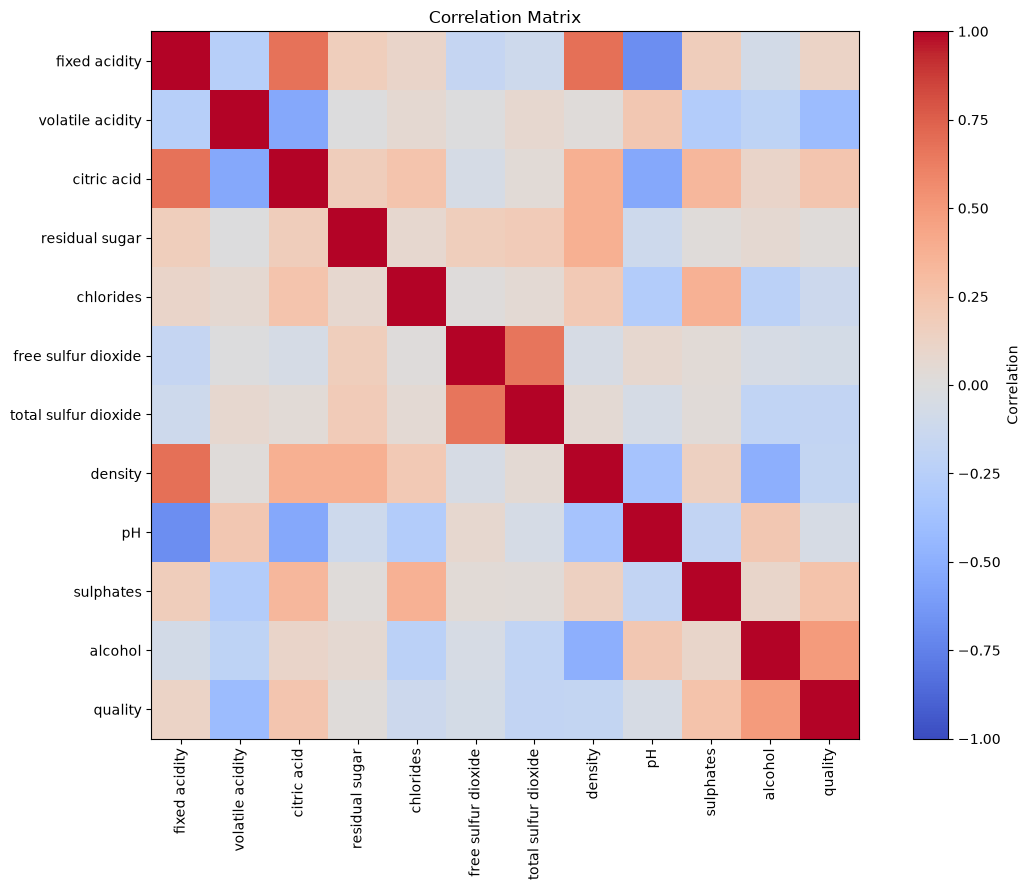

In [79]:
# Tampilkan Korelasi Matrix

corr = data.drop(columns=["Id"]).corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(12, 9))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()


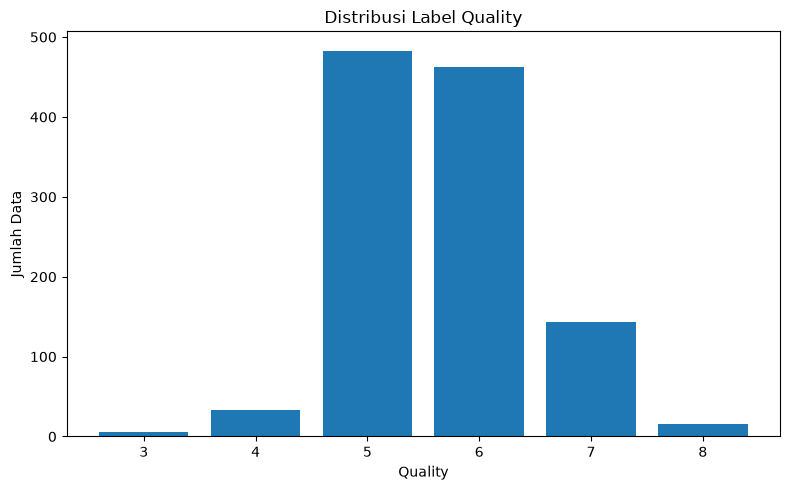

In [80]:
# Tampilkan distribusi label (quality) dalam bentuk visualisasi, misalnya menggunakan histogram atau bar plot.

quality_counts = data["quality"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(quality_counts.index.astype(str), quality_counts.values)
plt.xlabel("Quality")
plt.ylabel("Jumlah Data")
plt.title("Distribusi Label Quality")
plt.tight_layout()
plt.show()


## Silahkan Lakukan Exploratory Data Analysis (EDA) tambahan yang dibutuhkan. 

### Tambahan EDA
Analisis statistik sederhana berupa rata-rata setiap fitur berdasarkan nilai `quality`. Analisis ini digunakan untuk melihat apakah terdapat pola perubahan fitur terhadap kualitas wine.

Hasilnya digunakan sebagai eksplorasi awal dan tidak langsung dianggap sebagai bukti hubungan sebab-akibat.


In [81]:
feature_means_by_quality = (
    data.groupby("quality")[X.columns]
    .mean()
    .reset_index()
)

display(feature_means_by_quality.round(3))

,quality,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,3,8.450,0.898,0.212,2.667,0.105,8.167,24.500,0.998,3.362,0.550,9.692
1,4,7.809,0.700,0.166,2.567,0.095,14.848,40.606,0.997,3.391,0.638,10.261
2,5,8.161,0.585,0.240,2.540,0.092,16.613,55.299,0.997,3.302,0.613,9.902
3,6,8.318,0.505,0.264,2.445,0.085,15.215,39.942,0.997,3.324,0.677,10.655
4,7,8.851,0.394,0.387,2.760,0.075,14.538,37.490,0.996,3.287,0.744,11.483
5,8,8.806,0.410,0.432,2.644,0.070,11.062,29.375,0.996,3.241,0.766,11.938


# 2. Preprocessing




In [82]:
# NaN handling (drop, impute, etc.), duplicate handling, dan lain-lain.

print("Jumlah missing value sebelum handling:", data.isnull().sum().sum())

data_clean = data.drop(columns=["Id"]).copy()
print("Jumlah duplicate setelah Id dihapus sebelum handling:", data_clean.duplicated().sum())

data_clean = data_clean.drop_duplicates().copy()
print("Jumlah duplicate setelah handling:", data_clean.duplicated().sum())
print("Jumlah baris setelah duplicate handling:", len(data_clean))


Jumlah missing value sebelum handling: 0
Jumlah duplicate setelah Id dihapus sebelum handling: 125
Jumlah duplicate setelah handling: 0
Jumlah baris setelah duplicate handling: 1018


Jumlah data yang memiliki outlier pada minimal satu fitur setelah duplicate handling: 262


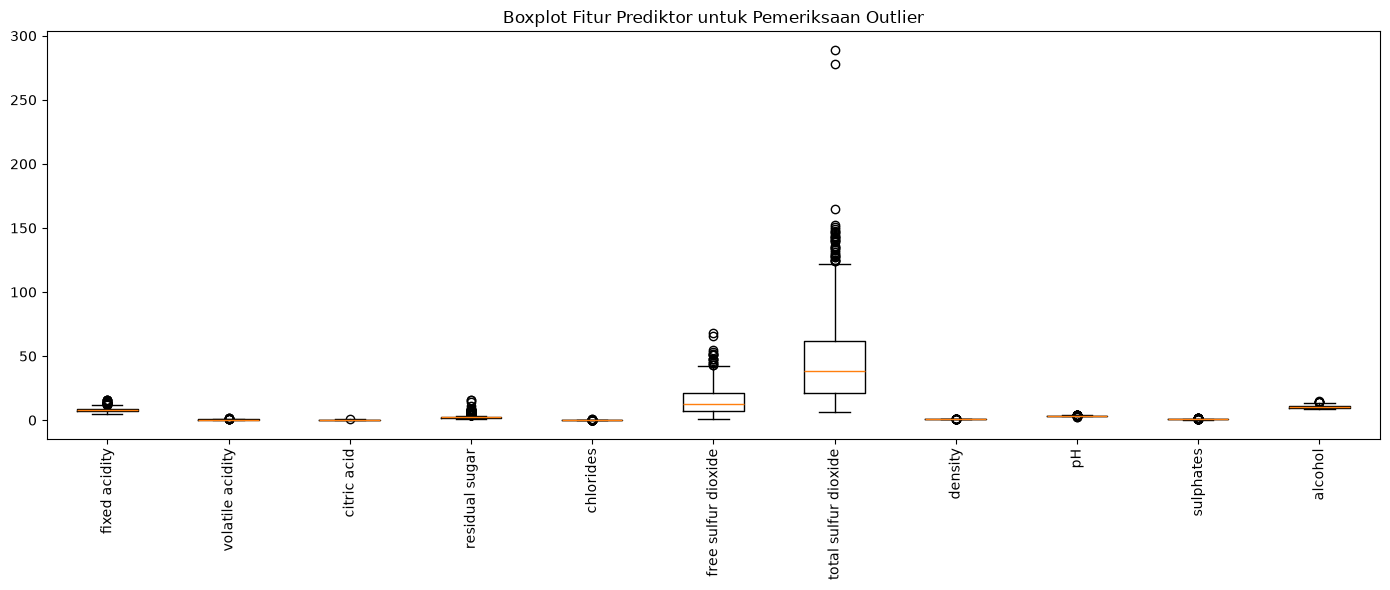

Outlier tidak langsung dihapus. Pengaruh penghapusan outlier akan diuji sebagai eksperimen tambahan pada data train.


In [83]:
# Periksa Outliers (jika diperlukan), misalnya menggunakan boxplot atau metode statistik lainnya. (Bisa dilakukan eksperimen dengan dan tanpa outlier untuk melihat perbedaan performa model)

X_clean_for_outlier = data_clean.drop(columns=["quality"])

Q1 = X_clean_for_outlier.quantile(0.25)
Q3 = X_clean_for_outlier.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_mask = ((X_clean_for_outlier < lower_bound) | (X_clean_for_outlier > upper_bound)).any(axis=1)
print("Jumlah data yang memiliki outlier pada minimal satu fitur setelah duplicate handling:", int(outlier_mask.sum()))

plt.figure(figsize=(14, 6))
plt.boxplot(X_clean_for_outlier.values, tick_labels=X_clean_for_outlier.columns, showfliers=True)
plt.xticks(rotation=90)
plt.title("Boxplot Fitur Prediktor untuk Pemeriksaan Outlier")
plt.tight_layout()
plt.show()

print("Outlier tidak langsung dihapus. Pengaruh penghapusan outlier akan diuji sebagai eksperimen tambahan pada data train.")


In [84]:
# Scaling data (jika diperlukan), misalnya menggunakan StandardScaler atau MinMaxScaler. (Bisa dilakukan eksperimen dengan dan tanpa scaling untuk melihat perbedaan performa model)
# Perhatikan data leakage saat melakukan scaling. Scaling harus dilakukan setelah membagi data menjadi train dan test set.


# 3. Eksperimen Model KNN


In [85]:
# Split data menjadi train dan test set. (misal 80% train, 20% test)
# Gunakan fungsi train_test_split dari sklearn.model_selection untuk membagi data menjadi train dan test set. Pastikan untuk memisahkan fitur (X) dan label (y) sebelum melakukan split.
# Gunakan stratify=y agar distribusi label pada train dan test set tetap sama dengan distribusi label pada dataset asli.
# Train model KNN menggunakan train set. Gunakan fungsi KNeighborsClassifier dari sklearn.neighbors untuk membuat model KNN. Lakukan eksperimen dengan berbagai nilai k (misal k=1, 3, 5, 7, 9) dan catat performa model pada train set dan test set.

# Fitur dan target terpisah.
X = data_clean.drop(columns=["quality"])
y = data_clean["quality"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Jumlah data train:", len(X_train))
print("Jumlah data test :", len(X_test))

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = [1, 3, 5, 7, 9]

metrics_to_test = [
    ("Euclidean", 1),
    ("Manhattan", 2),
    ("Minkowski", 3)
]

results = []

# Eksperimen tanpa scaling dan dengan scaling.
for scaling_name, Xtr, Xte in [
    ("Tanpa Scaling", X_train.values, X_test.values),
    ("StandardScaler", X_train_scaled, X_test_scaled)
]:
    for metric_name, p_value in metrics_to_test:
        for k in k_values:
            knn = KNeighborsClassifier(
                n_neighbors=k,
                weights="uniform",
                metric="minkowski",
                p=p_value
            )
            knn.fit(Xtr, y_train)

            pred_train = knn.predict(Xtr)
            pred_test = knn.predict(Xte)

            results.append({
                "Scaling": scaling_name,
                "Metric": metric_name,
                "p": p_value,
                "k": k,
                "Train Accuracy": accuracy_score(y_train, pred_train),
                "Test Accuracy": accuracy_score(y_test, pred_test),
                "Test Precision": precision_score(y_test, pred_test, average="weighted", zero_division=0),
                "Test Recall": recall_score(y_test, pred_test, average="weighted", zero_division=0),
                "Test F1": f1_score(y_test, pred_test, average="weighted", zero_division=0)
            })

results_df = pd.DataFrame(results).sort_values(
    by=["Test F1", "Test Accuracy"], ascending=False
).reset_index(drop=True)

print("Hasil seluruh eksperimen:")
display(results_df.round(4))

# Eksperimen tambahan dengan menghapus outlier hanya dari data train.
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train
lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

train_keep_mask = ~((X_train < lower_train) | (X_train > upper_train)).any(axis=1)
X_train_no_outlier = X_train.loc[train_keep_mask]
y_train_no_outlier = y_train.loc[train_keep_mask]

print("Jumlah data train sebelum outlier handling:", len(X_train))
print("Jumlah data train setelah outlier handling :", len(X_train_no_outlier))

scaler_no_outlier = StandardScaler()
X_train_no_outlier_scaled = scaler_no_outlier.fit_transform(X_train_no_outlier)
X_test_scaled_from_no_outlier = scaler_no_outlier.transform(X_test)

outlier_results = []
for metric_name, p_value in metrics_to_test:
    for k in k_values:
        knn = KNeighborsClassifier(
            n_neighbors=k,
            weights="uniform",
            metric="minkowski",
            p=p_value
        )
        knn.fit(X_train_no_outlier_scaled, y_train_no_outlier)
        pred_test = knn.predict(X_test_scaled_from_no_outlier)
        outlier_results.append({
            "Scaling": "StandardScaler + tanpa outlier train",
            "Metric": metric_name,
            "p": p_value,
            "k": k,
            "Test Accuracy": accuracy_score(y_test, pred_test),
            "Test Precision": precision_score(y_test, pred_test, average="weighted", zero_division=0),
            "Test Recall": recall_score(y_test, pred_test, average="weighted", zero_division=0),
            "Test F1": f1_score(y_test, pred_test, average="weighted", zero_division=0)
        })

outlier_results_df = pd.DataFrame(outlier_results).sort_values(
    by=["Test F1", "Test Accuracy"], ascending=False
).reset_index(drop=True)

print("Eksperimen tambahan dengan outlier train dihapus:")
display(outlier_results_df.round(4))

best_row = results_df.iloc[0]
print("Model terbaik dari eksperimen utama berdasarkan Test F1:")
print(best_row)


Jumlah data train: 814
Jumlah data test : 204
Hasil seluruh eksperimen:


,Scaling,Metric,p,k,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,StandardScaler,Minkowski,3,9,0.6400,0.6225,0.5930,0.6225,0.6048
1,StandardScaler,Minkowski,3,7,0.6474,0.5833,0.5572,0.5833,0.5691
2,StandardScaler,Manhattan,2,9,0.6474,0.5784,0.5544,0.5784,0.5627
3,StandardScaler,Manhattan,2,7,0.6548,0.5686,0.5516,0.5686,0.5593
4,StandardScaler,Minkowski,3,5,0.6732,0.5637,0.5531,0.5637,0.5568
5,StandardScaler,Manhattan,2,5,0.6781,0.5588,0.5416,0.5588,0.5498
6,StandardScaler,Euclidean,1,7,0.6646,0.5539,0.5293,0.5539,0.5398
7,StandardScaler,Minkowski,3,3,0.7592,0.5392,0.5416,0.5392,0.5397
8,StandardScaler,Euclidean,1,9,0.6511,0.5441,0.5232,0.5441,0.5293
9,StandardScaler,Euclidean,1,1,1.0000,0.5147,0.5269,0.5147,0.5196


Jumlah data train sebelum outlier handling: 814
Jumlah data train setelah outlier handling : 604
Eksperimen tambahan dengan outlier train dihapus:


,Scaling,Metric,p,k,Test Accuracy,Test Precision,Test Recall,Test F1
0,StandardScaler + tanpa outlier train,Minkowski,3,7,0.5931,0.5621,0.5931,0.5735
1,StandardScaler + tanpa outlier train,Minkowski,3,3,0.5833,0.5640,0.5833,0.5734
2,StandardScaler + tanpa outlier train,Euclidean,1,5,0.5686,0.5433,0.5686,0.5541
3,StandardScaler + tanpa outlier train,Manhattan,2,3,0.5588,0.5382,0.5588,0.5473
4,StandardScaler + tanpa outlier train,Manhattan,2,5,0.5637,0.5337,0.5637,0.5469
5,StandardScaler + tanpa outlier train,Minkowski,3,9,0.5637,0.5349,0.5637,0.5434
6,StandardScaler + tanpa outlier train,Minkowski,3,5,0.5588,0.5307,0.5588,0.5431
7,StandardScaler + tanpa outlier train,Manhattan,2,9,0.5637,0.5266,0.5637,0.5407
8,StandardScaler + tanpa outlier train,Euclidean,1,7,0.5539,0.5300,0.5539,0.5399
9,StandardScaler + tanpa outlier train,Manhattan,2,7,0.5588,0.5286,0.5588,0.5375


Model terbaik dari eksperimen utama berdasarkan Test F1:
Scaling           StandardScaler
Metric                 Minkowski
p                              3
k                              9
Train Accuracy          0.640049
Test Accuracy           0.622549
Test Precision           0.59302
Test Recall             0.622549
Test F1                 0.604768
Name: 0, dtype: object


# 4. Evaluasi Model


Model terbaik: k=9, metric=Minkowski, p=3, scaling=StandardScaler
Accuracy : 0.6225
Precision: 0.5930
Recall   : 0.6225
F1-Score : 0.6048

Classification Report:
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         7
           5       0.69      0.71      0.70        87
           6       0.59      0.68      0.63        82
           7       0.53      0.38      0.44        24
           8       0.00      0.00      0.00         3

    accuracy                           0.62       204
   macro avg       0.30      0.30      0.30       204
weighted avg       0.59      0.62      0.60       204



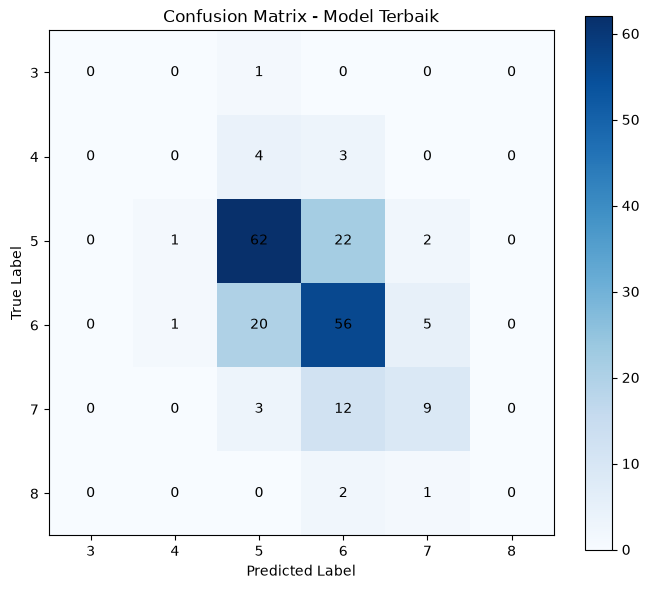

In [86]:
# Tampilkan evaluasi model KNN dengan metriks evaluasi yang sesuai dengan tipe masalah klasifikasi

# Evaluasi model terbaik dari eksperimen utama.
best_scaling = best_row["Scaling"]
best_metric = best_row["Metric"]
best_p = int(best_row["p"])
best_k = int(best_row["k"])

if best_scaling == "StandardScaler":
    Xtr_best = X_train_scaled
    Xte_best = X_test_scaled
else:
    Xtr_best = X_train.values
    Xte_best = X_test.values

best_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="uniform",
    metric="minkowski",
    p=best_p
)
best_knn.fit(Xtr_best, y_train)

pred_test_best = best_knn.predict(Xte_best)

print(f"Model terbaik: k={best_k}, metric={best_metric}, p={best_p}, scaling={best_scaling}")
print(f"Accuracy : {accuracy_score(y_test, pred_test_best):.4f}")
print(f"Precision: {precision_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")
print(f"Recall   : {recall_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, pred_test_best, average='weighted', zero_division=0):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, pred_test_best, zero_division=0))

cm = confusion_matrix(y_test, pred_test_best, labels=sorted(y.unique()))
plt.figure(figsize=(7, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Model Terbaik")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(range(len(sorted(y.unique()))), sorted(y.unique()))
plt.yticks(range(len(sorted(y.unique()))), sorted(y.unique()))

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()


# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen model KNN yang telah dilakukan. Bandingkan hasil antar eksperimen yang telah dilakukan. Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan.  

Setelah kolom `Id` dihapus, terdapat **125 duplicate**. Duplicate tersebut kemudian dihapus sehingga jumlah data menjadi **1.018 baris**. Data kemudian dibagi menjadi **80% data train dan 20% data test**.

Pada eksperimen KNN, dilakukan perbandingan antara data **tanpa scaling** dan data yang menggunakan **StandardScaler**. Hasil eksperimen menunjukkan bahwa penggunaan StandardScaler memberikan hasil yang lebih baik pada dataset ini. Hasil terbaik tanpa scaling memiliki Test Accuracy **0.5343** dan Test F1-score **0.5030**, sedangkan hasil terbaik dengan StandardScaler memiliki Test Accuracy **0.6225** dan Test F1-score **0.6048**.

Eksperimen juga dilakukan dengan beberapa nilai `k`, yaitu **1, 3, 5, 7, dan 9**, serta tiga metric jarak. Euclidean dengan `p=1`, Manhattan menggunakan `p=2`, dan Minkowski dengan `p=3`. Dari hasil percobaan, konfigurasi terbaik adalah **StandardScaler, Minkowski `p=3`, dan `k=9`**, dengan Test Accuracy **0.6225** dan Test F1-score **0.6048**.

Selain itu, dilakukan eksperimen tambahan dengan menghapus outlier hanya dari data train. Hasil terbaik dari eksperimen tersebut adalah **Minkowski `p=3` dengan `k=7`**, dengan Test Accuracy **0.5931** dan Test F1-score **0.5735**. Hasil ini lebih rendah dibandingkan hasil terbaik eksperimen utama, sehingga menghapus outlier belum memberikan hasil yang lebih baik pada dataset ini.

Dari classification report, model lebih baik dalam memprediksi kelas `quality` yang memiliki jumlah data lebih banyak, seperti kelas **5 dan 6**. Sementara itu, kelas **3, 4, dan 8** masih sulit diprediksi karena jumlah datanya lebih sedikit.


# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan. Saran dapat berupa rekomendasi untuk eksperimen selanjutnya, perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

KNN dapat digunakan untuk mengklasifikasikan `quality` pada dataset WineQT. Setelah `Id` dihapus dan duplicate ditangani, diperoleh **1.018 data** untuk digunakan dalam eksperimen.

Dari percobaan beberapa nilai `k`, metric jarak, dan scaling, hasil terbaik diperoleh dengan **StandardScaler, Minkowski `p=3`, dan `k=9`**. Model tersebut menghasilkan **Test Accuracy 0.6225** dan **Test F1-score 0.6048**.

Hasil eksperimen juga menunjukkan bahwa penggunaan StandardScaler memberikan hasil yang lebih baik dibandingkan tanpa scaling. Sementara itu, menghapus outlier dari data train belum meningkatkan hasil model.

Untuk percobaan selanjutnya, dapat mencoba lebih banyak nilai `k` dan menggunakan **cross-validation** agar dapat memilih model dengan lebih baik. Selain itu, **macro F1-score** dapat digunakan untuk melihat performa model pada setiap kelas, terutama karena jumlah data pada setiap kelas `quality` tidak sama.

